In [1]:
import sys
import seaborn as sns
import pandas as pd
import numpy as np
import multianndata as mad
import cna
import scanpy as sc
from matplotlib import pyplot as plt
from plotnine import *

In [2]:
# parameters
resolution = "major_cell_types"
analysis_name = "no_expr_pc_covars"
celltype = "NK"

In [4]:
# read in the multi anndata with GeNA phenotype information
madata = cna.read(
    f"/directflow/SCCGGroupShare/projects/blabow/tenk10k_phase1/data_processing/csa_qtl/output/multianndata/{resolution}/{analysis_name}/{celltype}_scDataObject.dimreduc.pca.gena_pheno.h5ad"
)


Only considering the two last: ['.gena_pheno', '.h5ad'].
Only considering the two last: ['.gena_pheno', '.h5ad'].


Import umap and cell function scores from Lawrence's analysis

In [21]:
umap_nk = pd.read_csv(
    "/directflow/SCCGGroupShare/projects/blabow/tenk10k_phase1/data_processing/csa_qtl/data/h5/NK_cellstate/NK_cellstate_umap_subtypes.csv", index_col=0
)
cell_func_scores = pd.read_csv(
    "/directflow/SCCGGroupShare/projects/blabow/tenk10k_phase1/data_processing/csa_qtl/data/h5/NK_cellstate/NK_cell_function_scores.csv"
)

In [25]:
umap_nk

,UMAP1,UMAP2,celltype
AAACCCACACCCAATA_S0012b,6.187087,10.757096,NK1
AAACCCACATAGAATG_S0012b,4.503816,7.669902,NK1
AAACCCACATCGCTCT_S0012b,4.311159,13.511112,NK1
AAACCCACATGGGATG_S0012b,6.395042,7.039422,NK1
AAACGAAAGCGAACTG_S0012b,4.829165,10.319350,NK1
...,...,...,...
TTGTTGTCAACTCATG_S0170,1.956484,9.725125,NK_CD56bright
TTGTTGTCAGACAAGC_S0170,0.962554,10.443008,NK_CD56bright
TTTCATGAGGACGCAT_S0170,1.306305,11.687542,NK_CD56bright
TTTCCTCGTAGGTCAG_S0170,0.897204,11.009116,NK_CD56bright


In [26]:
madata.obsm["X_umap"] = umap_nk.reindex(madata.obs.index).loc[:, ["UMAP1", "UMAP2"]].to_numpy(dtype="float32")

In [27]:
madata.obs = madata.obs.join(umap_nk.loc[:, "celltype"])

In [28]:
madata.obs

,id,sequencing_library,cohort,wg2_scpred_prediction,npheno_16:128736:C:G,npheno_11:128246346:T:TA,npheno_19:16331208:G:A,npheno_2:111050100:G:A,npheno_21:13891042:T:C,npheno_1:143272081:G:C,npheno_3:15163210:T:TC,npheno_17:35466189:C:T,npheno_5:137537935:A:AC,npheno_13:112149033:C:CCCTGTGGAAGCCCTGACTCCCAGTGTGATAGTACCTGTGGAAACCCTGACCCCTGTGTGATGGTA,npheno_4:87380068:G:A,npheno_3:61434635:G:GC,npheno_10:38578997:G:T,celltype
AAACCCAAGAGTCTGG_S0056a,CPG247833,S0056a,BioHEART,NK,0.010931,-0.010724,0.033785,-0.041284,0.011425,-0.008120,0.062569,-0.019490,0.039419,-0.019314,-0.033993,0.027583,-0.008421,NK3
AAACCCAAGCCGCTTG_S0056a,CPG248245,S0056a,BioHEART,NK,0.033553,-0.001591,0.029158,-0.021010,0.022114,-0.019987,0.032852,-0.067030,-0.004417,0.016862,-0.059629,0.036330,-0.002389,NK1
AAACCCAAGTCATAGA_S0056a,CPG248245,S0056a,BioHEART,NK,-0.089434,-0.042308,-0.033424,0.093543,-0.030951,0.136585,-0.109375,0.058099,-0.113052,-0.116055,0.105190,-0.105684,0.101118,NK1
AAACCCACAAGCACCC_S0056a,CPG248245,S0056a,BioHEART,NK,-0.113428,-0.014529,-0.103215,0.055163,-0.029837,0.147151,-0.144392,0.041771,-0.113923,-0.116585,0.115061,-0.118801,0.096078,NK1
AAACCCATCAATCCAG_S0056a,CPG248245,S0056a,BioHEART,NK,0.028276,-0.007459,0.028156,-0.016034,0.019848,-0.025024,0.038846,-0.066954,-0.008007,0.016663,-0.056341,0.039213,0.004785,NK1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTCAAGTTTGC_S0176,CPG500249,S0176,BioHEART,NK,-0.086536,-0.042795,-0.095730,0.070123,-0.042468,0.129070,-0.118989,0.090724,-0.099509,-0.111263,0.118671,-0.115210,0.091634,NK1
TTTGGTTGTTGACTAC_S0176,CPG500082,S0176,BioHEART,NK,0.045585,-0.015396,0.033319,-0.038735,0.027949,-0.063422,0.051432,-0.074089,0.016907,0.031068,-0.059566,0.054874,-0.016452,NK1
TTTGTTGAGATCACTC_S0176,CPG500249,S0176,BioHEART,NK,-0.014086,-0.006350,-0.018503,-0.010602,0.006299,-0.059181,0.019430,0.000894,0.062523,0.014566,-0.034049,0.020636,-0.015924,NK1
TTTGTTGGTGAGCGAT_S0176,CPG500249,S0176,BioHEART,NK,-0.008125,-0.027532,-0.017589,-0.032588,0.019286,-0.045165,0.047095,-0.108626,0.040142,-0.009200,-0.040163,0.032258,-0.040140,NK3


/directflow/SCCGGroupShare/projects/blabow/.conda/envs/gena-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
/directflow/SCCGGroupShare/projects/blabow/.conda/envs/gena-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
/directflow/SCCGGroupShare/projects/blabow/.conda/envs/gena-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


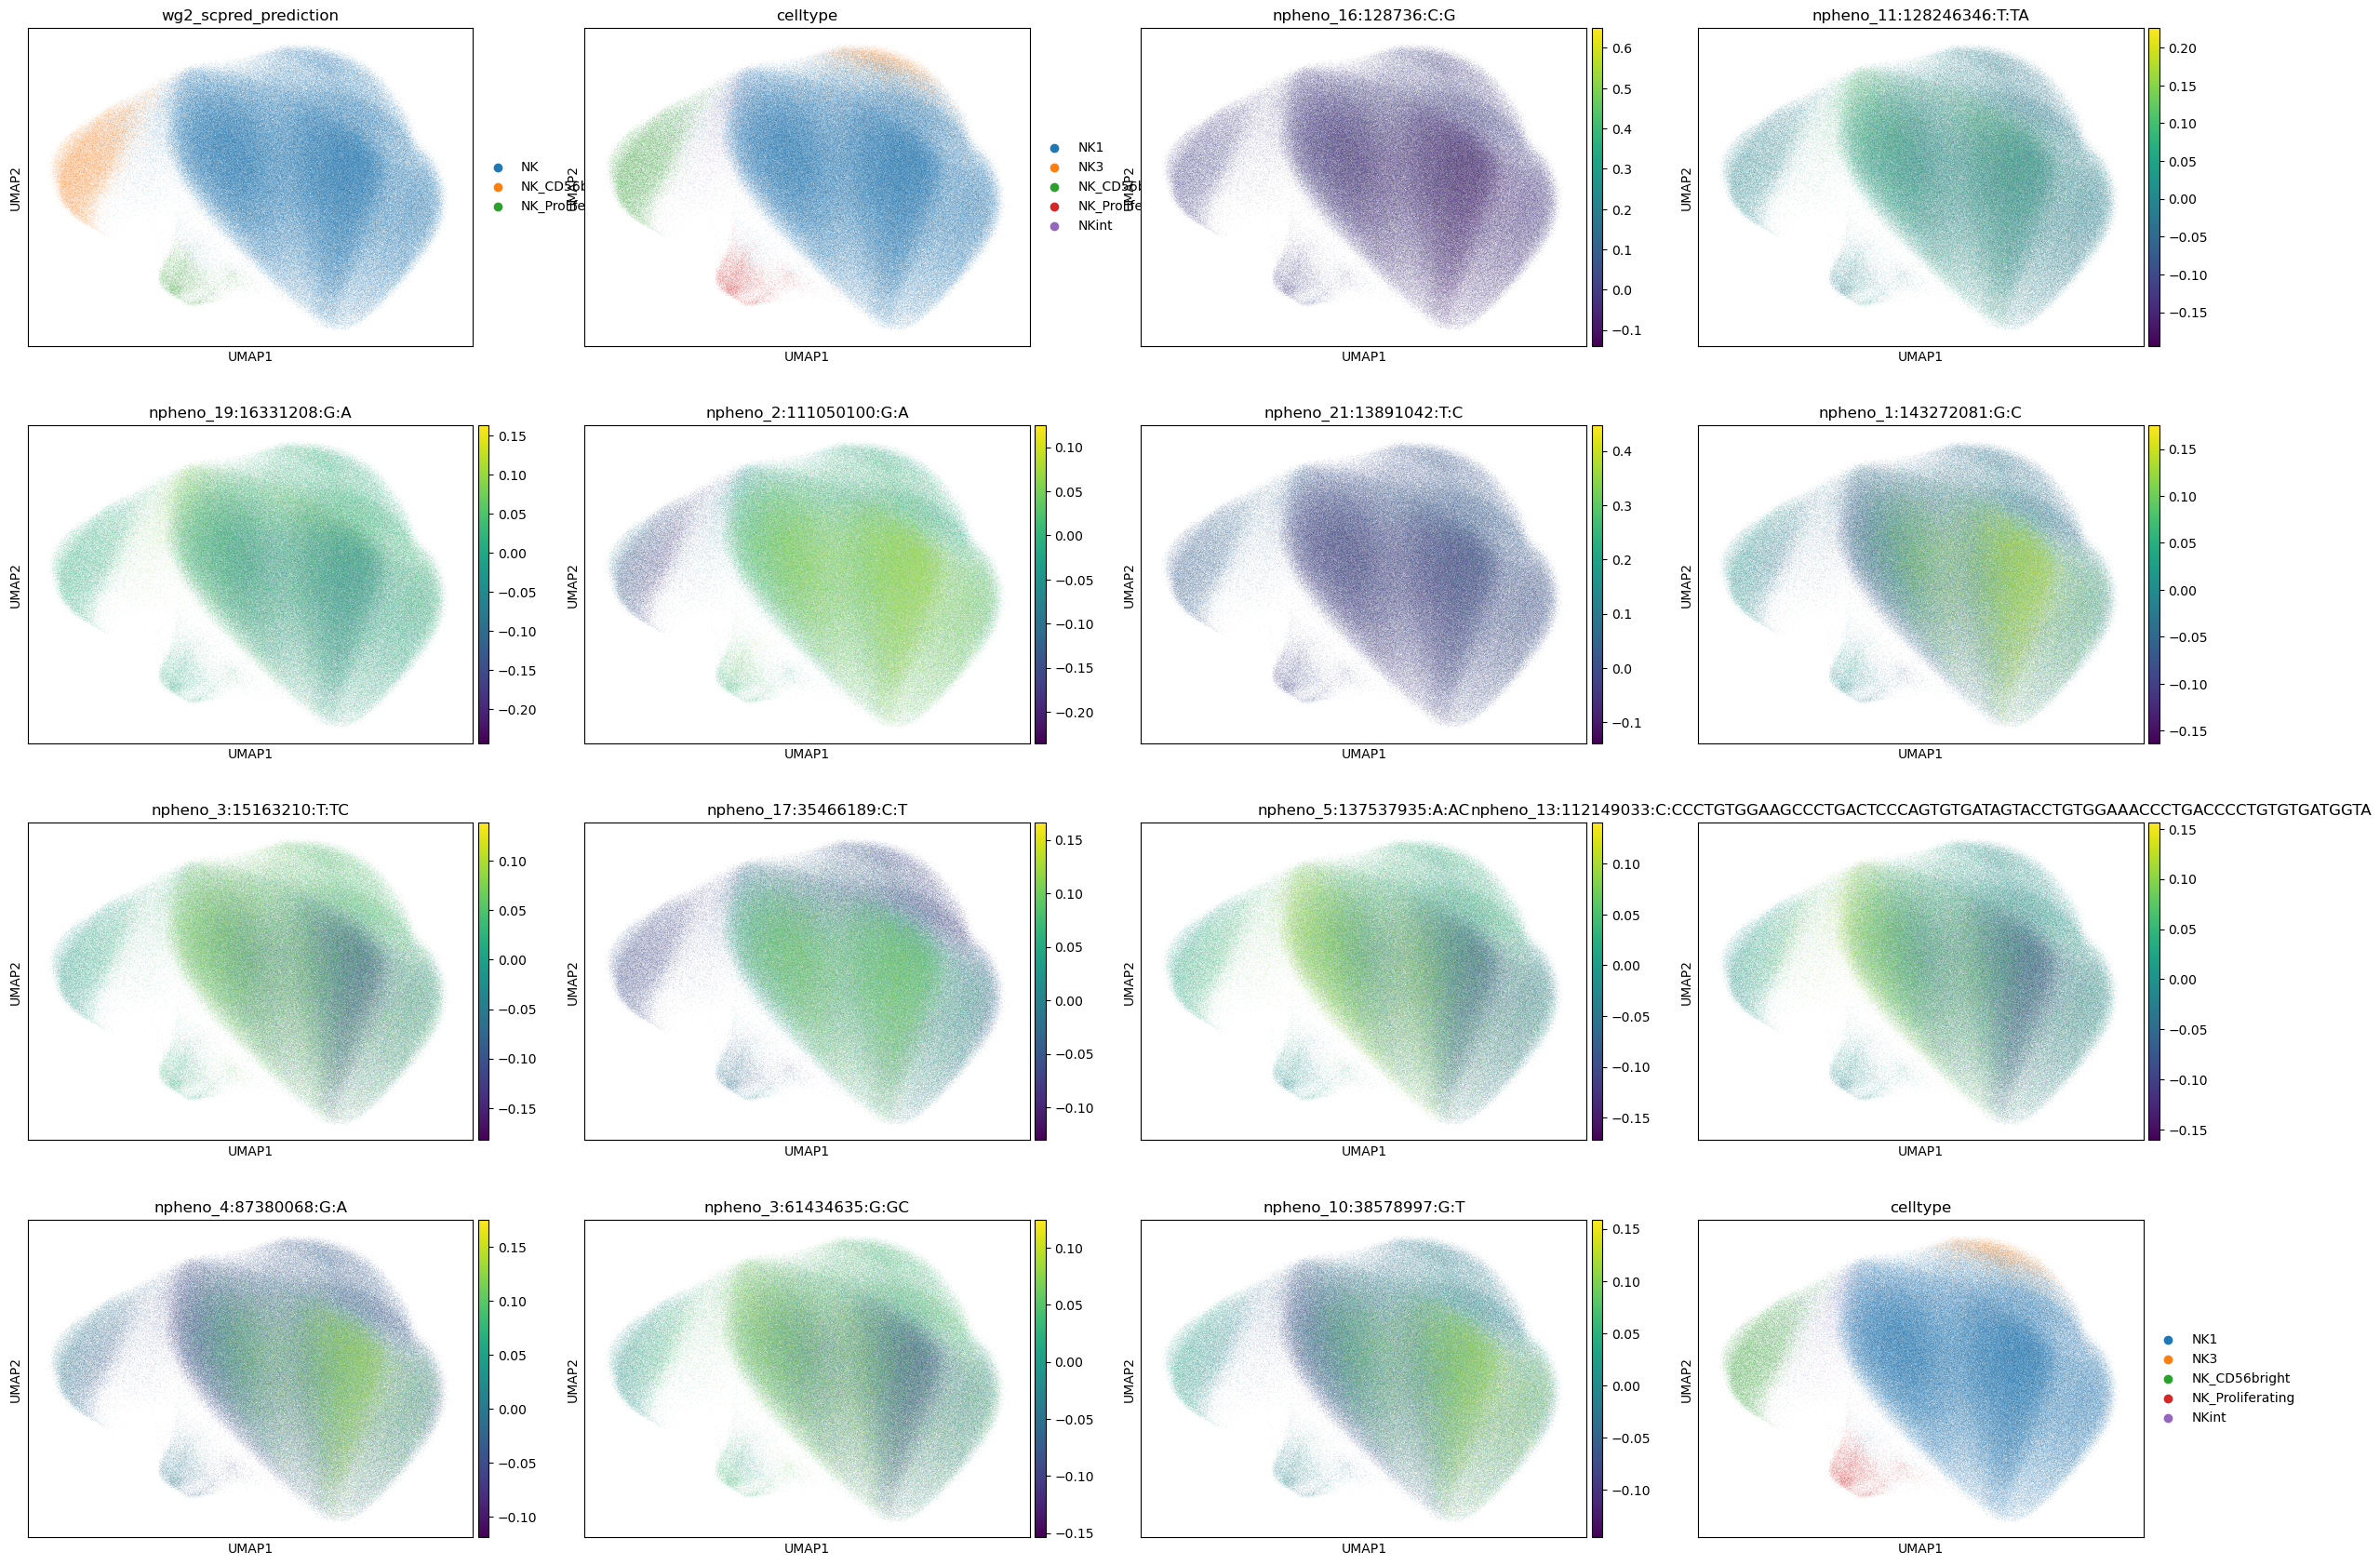

In [30]:
# plot neighbourhood abundance correllations

sc.pl.umap(
    madata, color=["wg2_scpred_prediction", "celltype"] + madata.obs.columns[4:].tolist()
)

# Validation - replicating Onek1k csaQTLs

/directflow/SCCGGroupShare/projects/blabow/.conda/envs/gena-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


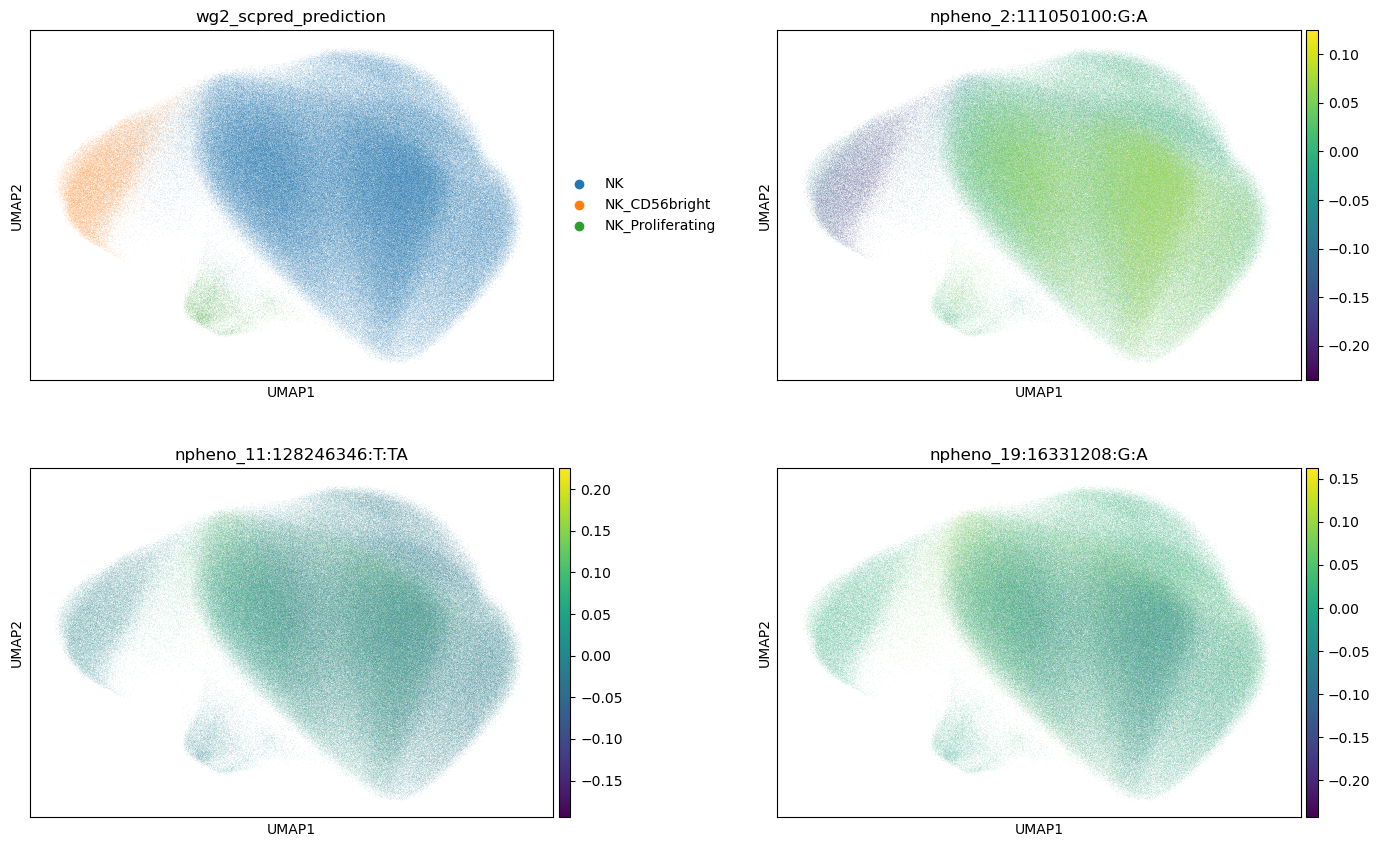

In [32]:
onek1k_intersecting_nk = [
    "npheno_2:111050100:G:A",
    "npheno_11:128246346:T:TA",     # "11:128246346:T:T" in GeNA paper 
    "npheno_19:16331208:G:A",
]
sc.pl.umap(
    madata,
    color=["wg2_scpred_prediction"] + onek1k_intersecting_nk,
    wspace=0.3,
    ncols=2
)

Here we can see replication of the csaQTL discovered in the onek1k cohort. This is most obvious for 2:111050100:G:A, where the alternate allele is associated with depletion of the NK CD65 bright cells. 